# **Bioinformatics Project | Computational Drug Discovery | Part-4**

In Part 4, we will be comparing several ML algorithms for building regression models of acetylcholinesterase inhibitors.


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor

In [24]:
df = pd.read_csv('Data/acetylcholinesterase_03_bioactivity_data_3class_pIC50_pubchem_fp.csv')
df.head()

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.12
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.00
2,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4.30
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.52
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.10


In [25]:
x = df.drop(columns= ['pIC50'])
y = df['pIC50']

In [26]:
print(x.shape)
print(y.shape)

(7174, 881)
(7174,)


In PubChem fingerprints most of the features are almost useless. This is because their value rarely changes across molecules. Now a ML model does not benefit from such features. Thus we may remove features that have less variance throughout the column.
For binary features variance is ```p*(1-p)```, where p is fraction of 1s. In our case let's take p = 0.8. Which makes our threshold variance as 0.16

In [27]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold= 0.16)
x = selection.fit_transform(x)
x.shape

(7174, 146)

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

In [34]:
from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor,
    BaggingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

selected = [
    ("ExtraTreesRegressor", ExtraTreesRegressor),
    ("RandomForestRegressor", RandomForestRegressor),
    ("GradientBoostingRegressor", GradientBoostingRegressor),
    ("AdaBoostRegressor", AdaBoostRegressor),
    ("HistGradientBoostingRegressor", HistGradientBoostingRegressor),
    ("XGBRegressor", XGBRegressor),
    ("BaggingRegressor", BaggingRegressor),
    ("DecisionTreeRegressor", DecisionTreeRegressor),
    ("LinearRegression", LinearRegression)
]

In [35]:
clf = LazyRegressor(verbose= 1, ignore_warnings= True, custom_metric= None, regressors= selected)
models, predictions = clf.fit(x_train, x_test, y_train, y_test)

'tuple' object has no attribute '__name__'
Invalid Regressor(s)


  0%|          | 0/9 [00:00<?, ?it/s]

{'Model': 'ExtraTreesRegressor', 'R-Squared': 0.2053114898456987, 'Adjusted R-Squared': 0.11523033884994716, 'RMSE': 1.3626439773663603, 'Time taken': 28.184258460998535}
{'Model': 'RandomForestRegressor', 'R-Squared': 0.45074989201478144, 'Adjusted R-Squared': 0.3884901748052769, 'RMSE': 1.1328411327562453, 'Time taken': 19.379706382751465}
{'Model': 'GradientBoostingRegressor', 'R-Squared': 0.35917679017536075, 'Adjusted R-Squared': 0.2865368921672883, 'RMSE': 1.2236382678950277, 'Time taken': 3.3444643020629883}
{'Model': 'AdaBoostRegressor', 'R-Squared': 0.16341744882595377, 'Adjusted R-Squared': 0.06858743914318144, 'RMSE': 1.3981003202021716, 'Time taken': 1.6389710903167725}
{'Model': 'HistGradientBoostingRegressor', 'R-Squared': 0.4585441016555114, 'Adjusted R-Squared': 0.3971678895760896, 'RMSE': 1.1247745435859389, 'Time taken': 2.8553497791290283}
{'Model': 'XGBRegressor', 'R-Squared': 0.44475890146543595, 'Adjusted R-Squared': 0.38182008128993417, 'RMSE': 1.1390026552280352

In [36]:
predictions

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
HistGradientBoostingRegressor,0.40,0.46,1.12,2.86
RandomForestRegressor,0.39,0.45,1.13,19.38
XGBRegressor,0.38,0.44,1.14,0.53
BaggingRegressor,0.35,0.42,1.17,1.96
GradientBoostingRegressor,0.29,0.36,1.22,3.34
LinearRegression,0.18,0.26,1.31,0.21
ExtraTreesRegressor,0.12,0.21,1.36,28.18
AdaBoostRegressor,0.07,0.16,1.40,1.64
DecisionTreeRegressor,0.07,0.16,1.40,0.34


**Bar plot for R<sup>2</sup> values**

[(0.0, 1.0)]

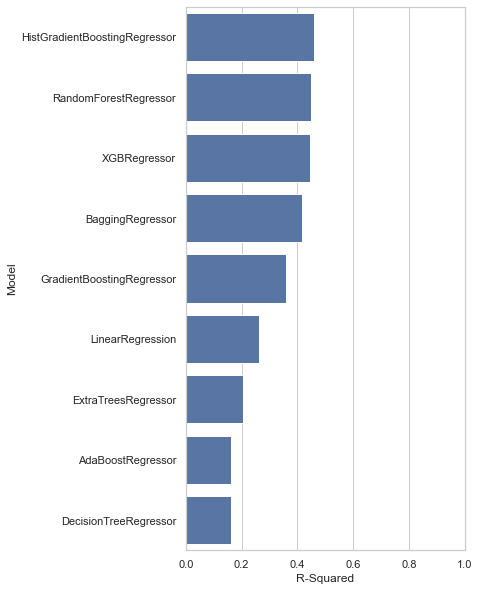

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions.index, x="R-Squared", data=predictions)
ax.set(xlim=(0, 1))


**Bar plot for RMSE Values**

[(0.0, 10.0)]

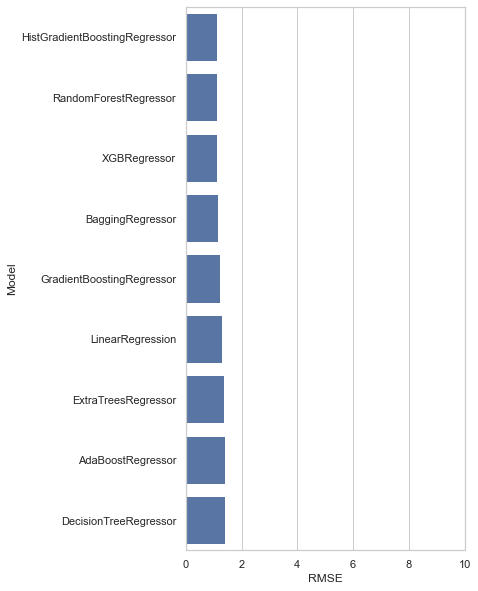

In [38]:
plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions.index, x="RMSE", data=predictions)
ax.set(xlim=(0, 10))

**Bar plot for calculation time**

[(0.0, 10.0)]

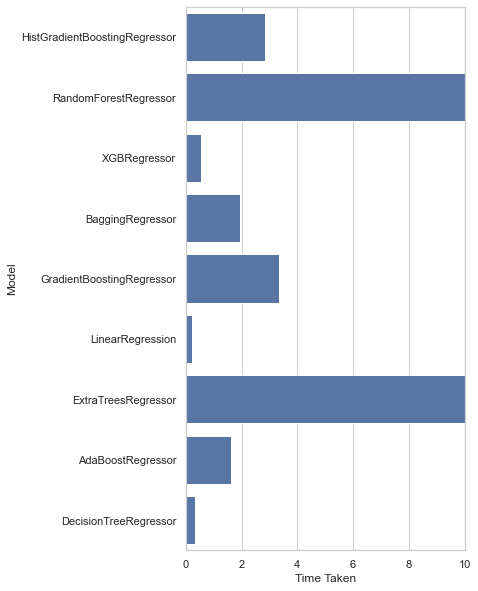

In [39]:
plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions.index, x="Time Taken", data=predictions)
ax.set(xlim=(0, 10))

## **Let's Choose RandomForestRegressor as our final model**